

# Sector Rotation — Winners and Losers Across the War Phases

**Goal:** compute each sector index's cumulative return within each of the 6 war phases, and test the 'war winners vs losers' thesis against the data rather than assuming it.

In [1]:
import sys
from pathlib import Path
# find the project root (dir containing src/etl/config.py) and import our DB helper
_p = Path.cwd()
for _c in [_p, *_p.parents]:
    if (_c / 'src' / 'etl' / 'config.py').exists():
        sys.path.insert(0, str(_c / 'src' / 'etl')); ROOT = _c; break
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import config
engine = config.get_engine()
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
print('connected to', config.DB_NAME)

connected to war_shock_lab


In [2]:
lvl = pd.read_sql("SELECT date, index_name, level FROM index_levels "
                  "WHERE index_name NOT IN ('nifty50','sensex') ORDER BY date",
                  engine, parse_dates=['date'])
phases = pd.read_sql('SELECT phase_id, name, start_date, end_date FROM phases '
                     'ORDER BY phase_id', engine, parse_dates=['start_date','end_date'])
phases['end_date'] = phases['end_date'].fillna(pd.Timestamp('2100-01-01'))
phases[['phase_id','name']]

,phase_id,name
0,1,Pre-war baseline
1,2,Acute war I
2,3,First ceasefire
3,4,Naval blockade / brinkmanship
4,5,MoU / de-escalation
5,6,Renewed conflict


### What is "cumulative index return"?

For a given **sector** over a given **phase**, the next cell computes:

$$\text{cumulative return} = \left(\frac{\text{index level on the *last* trading day of the phase}}{\text{index level on the *last trading day of the previous* phase}} - 1\right)\times 100\%$$

In plain words: **"if you had bought this sector index at the close of the day before the phase began and sold it on the phase's last day, what total % would you have made or lost?"** It is the **compounded total move over the whole window** — every daily up/down move rolled into one number — **not** an average of the daily returns, and **not** annualised.

**Why the base is the *previous* phase's close (chaining), not the first close inside the phase.** A phase boundary is drawn at a war event, and the market's reaction to that event *is* the phase's opening move. If the base were the first close inside the phase, that opening move would be silently thrown away — you would be measuring from a level that already contains the shock. Phase 6 is the clearest case: it begins on the ceasefire break (`wt_0374`, 2026-07-07) whose market reaction is the **−2.12% crash on 07-08**. Based on the first in-phase close, phase 6 measured only the *rebound off that low* and reported almost every sector positive. The same bias applied to every other phase — acute war I dropped 02-28's move, the blockade phase dropped 04-13's.

Chaining makes each phase pick up exactly where the previous one left off, so **the phases compound to the full-period return with nothing lost at the seams**. The trade-off is unchanged and still worth remembering: the number depends entirely on **where the phase boundaries are drawn**, so a boundary is an analytical claim, not a neutral choice.

**Conclusion — the 6 phases:** the war is split into 6 dated windows (pre-war baseline → acute war → ceasefire → blockade → de-escalation → renewed conflict). Computing one chained cumulative return per sector *per phase* is what lets us see **rotation** — which sectors lead in which regime — instead of one blended number for the whole war.

In [3]:
def phase_of(d):
    m = phases[(d >= phases.start_date) & (d <= phases.end_date)]
    return int(m.phase_id.iloc[0]) if len(m) else np.nan
lvl['phase_id'] = lvl['date'].map(phase_of)

# --- comparability guard for the open-ended final phase ---------------------
# Yahoo has no data for ^CNXENERGY / ^CNXAUTO / ^CNXMETAL between 2026-07-20 and
# 2026-07-24 — a permanent upstream gap, not a fetch failure (every alternate
# symbol 404s). Those three sectors therefore stop on 07-17 while bank/IT/pharma
# run to 07-24. Since cumulative return is last-level / first-level, comparing
# sectors measured over unequal windows is apples-to-oranges. Truncate the final
# phase to the last date EVERY sector has, so the column is row-comparable.
last_phase = int(phases.phase_id.max())
cover = lvl[lvl.phase_id == last_phase].groupby('index_name')['date'].max()
common_end = cover.min()
print(f'phase {last_phase} per-sector last day:')
print(cover.dt.date.to_string())
print(f'\ncommon end date -> {common_end.date()}')
drop = (lvl.phase_id == last_phase) & (lvl.date > common_end)
print(f'dropping {int(drop.sum())} row(s) beyond it so every sector spans the same window\n')
lvl = lvl[~drop]

# --- cumulative return per (sector, phase), CHAINED across phase boundaries --
# Base = the last close of the PREVIOUS phase, not the first close inside this one.
# Using the first in-phase close silently discards that phase's own opening move:
# phase 6 begins on the ceasefire break (wt_0374, 2026-07-07) whose market reaction
# is the -2.12% crash on 07-08, so a first-in-phase base measured the rebound off
# the low and threw away the crash itself. The same bias applied to every phase
# (acute war I dropped 02-28's move, the blockade phase dropped 04-13's).
# Chaining makes each phase pick up exactly where the previous one ended, so the
# phases compound to the full-period return with nothing lost at the seams.
# (Explicit loop rather than groupby.apply: pandas 3.0 no longer exposes the group
# key as `g.name` on the passed frame, and the previous-phase lookup needs it.)
rows = []
for sector, s_all in lvl.sort_values('date').groupby('index_name'):
    for pid, g in s_all.groupby('phase_id'):
        prior = s_all[s_all['date'] < g['date'].iloc[0]]
        base = prior['level'].iloc[-1] if len(prior) else g['level'].iloc[0]
        rows.append({'index_name': sector, 'phase_id': pid,
                     'cum_return_pct': (g['level'].iloc[-1] / base - 1) * 100})
cr = pd.DataFrame(rows)
mat = cr.pivot(index='index_name', columns='phase_id', values='cum_return_pct').round(2)
mat.columns = [phases.set_index('phase_id').loc[p,'name'] for p in mat.columns]

# trading-day count behind every cell, so no column is read without its sample size
nd = lvl.groupby(['index_name','phase_id']).size().unstack()
nd.columns = mat.columns
print('trading days per sector per phase:')
print(nd.to_string())
mat

phase 6 per-sector last day:
index_name
nifty_auto      2026-07-17
nifty_bank      2026-07-31
nifty_energy    2026-07-17
nifty_it        2026-07-31
nifty_metal     2026-07-17
nifty_pharma    2026-07-31

common end date -> 2026-07-17
dropping 30 row(s) beyond it so every sector spans the same window

trading days per sector per phase:
              Pre-war baseline  Acute war I  First ceasefire  Naval blockade / brinkmanship  MoU / de-escalation  Renewed conflict
index_name                                                                                                                        
nifty_auto                  39           23                3                             42                   15                 9
nifty_bank                  40           23                3                             42                   15                 9
nifty_energy                39           23                3                             42                   15                 9
nifty_it 

,Pre-war baseline,Acute war I,First ceasefire,Naval blockade / brinkmanship,MoU / de-escalation,Renewed conflict
index_name,,,,,,
nifty_auto,-2.240,-13.440,9.300,-1.300,4.030,-0.930
nifty_bank,1.370,-12.910,6.060,1.610,2.600,0.390
nifty_energy,2.120,-3.960,4.490,5.570,0.600,-0.520
nifty_it,-19.830,2.610,-1.190,-10.420,-1.870,7.150
nifty_metal,7.170,-3.910,5.050,4.030,-1.030,-2.240
nifty_pharma,0.710,-4.720,1.350,9.990,6.100,-0.860


**Conclusion — reading the matrix:** the war-regime story is in the columns. In **Acute war I** every sector is negative *except IT* (+2.6%) — the same energy-vs-IT hedge we saw in notebook 01, now at the phase level. In **Naval blockade / brinkmanship**, defensive/real-asset sectors lead: **Pharma +10.0%, Energy +5.6%, Metal +4.0%**, while IT (−10.4%) gives back its safe-haven premium as the shock persists. So sector leadership genuinely *rotates* with the war phase rather than staying fixed.

> **Renewed conflict (phase 6) — now a coherent regime, after two corrections.**
>
> **1. The phase starts on the ceasefire break, 2026-07-07.** The curated event `wt_0374` (*"Iran strikes Qatari LNG tanker (Nakilat); US revokes Iran oil deal"*, **severity 4, escalation_dir = +1**) is dated 07-07. With phase 6 previously starting on 07-08, that severity-4 **escalation** event sat on the last day of phase 5 — the phase labelled *"MoU / de-escalation"*. That was a straight mislabel, and it is why the boundary moved.
>
> Note the event date and the *reaction* date are legitimately different. 07-07 was flat in India (nifty50 **−0.13%**); the crash is on 07-08 (**−2.12%**). A 07-07 US-time event breaks after the 15:30 IST close, so India's first chance to react is the next session. The phase is defined on the **event** date; chaining the base (below) is what pulls the 07-08 reaction inside the window.
>
> **2. The base is chained to the previous phase's close.** Together these two changes flip the picture: phase 6 previously showed 5 of 6 sectors positive, which read as "war lifts all sectors". It now reads **IT +7.2%, bank +0.4%, energy −0.5%, pharma −0.9%, auto −0.9%, metal −2.2% — 4 of 6 negative.** That is a miniature of Acute war I, where IT was also the lone winner: escalation hurts the broad market while the dollar-earning, oil-insensitive sector outperforms. The earlier all-positive column was an artifact of measuring the rebound off a crash-day floor, exactly as suspected.
>
> **Remaining caveat — the window is still short and still truncated.** Phase 6 covers **2026-07-07 → 2026-07-17, 9 trading days** for every sector. It stops at 07-17 rather than the latest date because **Yahoo has no data for `^CNXENERGY`, `^CNXAUTO` and `^CNXMETAL` between 2026-07-20 and 2026-07-24** — a permanent gap on the provider's side, not a fetch failure (every alternate symbol 404s). Without the truncation those three would span 9 days against bank/IT/pharma's 14, and the column would not be row-comparable. **Cost:** 5 genuine bank/IT/pharma days are excluded. Nine days is a suggestive regime signal, **not** an established one — and it cannot extend past 07-17 unless the three gapped series are backfilled from NSE direct or a paid vendor.

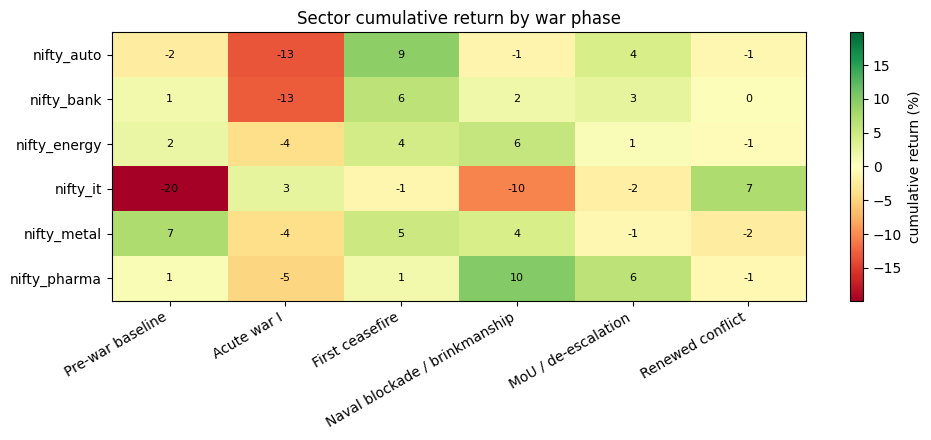

In [4]:
%matplotlib inline
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(10,4.5))
vmax = np.nanmax(np.abs(mat.values))
im = ax.imshow(mat.values, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=30, ha='right')
ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i,j]
        if not np.isnan(v): ax.text(j,i,f'{v:.0f}',ha='center',va='center',fontsize=8)
fig.colorbar(im, label='cumulative return (%)')
ax.set_title('Sector cumulative return by war phase')
plt.tight_layout(); plt.show()

**How to read this heatmap:** rows = sectors, columns = war phases, each cell = that sector's chained cumulative return in that phase. **Green = positive, red = negative**, and the colour is scaled symmetrically around zero (`vmin=-vmax, vmax=+vmax`), so the deepest red and deepest green mark the biggest moves in either direction. **Conclusion:** the eye is drawn to the **red block down the "Acute war I" column** (broad sell-off, autos −13.4% and banks −12.9% deepest) and the **green in Pharma/Energy during the blockade column** — visually the same rotation the numbers gave us. The **"Renewed conflict" column is now mostly red** (4 of 6 sectors negative) with **IT the lone strong green at +7.2%**, echoing the Acute war I pattern: escalation hurts the broad market, the dollar-earning sector outperforms. Read that column with its 9-day sample size in mind.

In [5]:
# Acute-war-phase (2) ranking: does the winner/loser thesis hold?
acute = cr[cr.phase_id == 2].sort_values('cum_return_pct', ascending=False)
acute[['index_name','cum_return_pct']].reset_index(drop=True)

,index_name,cum_return_pct
0,nifty_it,2.612
1,nifty_metal,-3.905
2,nifty_energy,-3.960
3,nifty_pharma,-4.721
4,nifty_bank,-12.907
5,nifty_auto,-13.444


In [6]:
# Persist the sector×phase matrix so Power BI reads the SAME numbers the notebook
# computed — chained base + phase-6 truncation are not reproducible in DAX.
nd2 = (lvl.groupby(['index_name', 'phase_id']).size()
          .rename('trading_days').reset_index())
out = cr.merge(nd2, on=['index_name', 'phase_id'])
out['cum_return_pct'] = out['cum_return_pct'].round(4)
out['window_end'] = lvl.groupby('phase_id')['date'].max() \
                       .reindex(out['phase_id']).dt.date.values
out.to_sql('sector_phase_returns', engine, if_exists='replace', index=False)
print(f'wrote {len(out)} rows to sector_phase_returns')

wrote 36 rows to sector_phase_returns


**Conclusion — acute-war ranking:** ranked cleanly, the acute-war phase puts **IT on top (+2.6%)** and **Autos (−13.4%) and Banks (−12.9%) at the bottom**. This is the "war winners vs losers" thesis, and it holds up: the **rate- and domestic-demand-sensitive** sectors (autos, banks — hurt by higher oil→inflation→rates and weaker consumer demand) are the clear losers, while the **dollar-earning, oil-neutral** sector (IT) is the only winner. Energy (−4.0%) and Metal (−3.9%) sit mid-pack and are now **effectively tied** — chaining the base pulled the war's opening day (02-28) into this phase, which hit energy harder than the unchained version showed. Energy does not rally here because in *this* dataset the war is an oil-*supply-shock / demand-fear* story for Indian equities rather than a windfall for domestic energy names.

### Finding
The heatmap confirms clear rotation: energy and metals hold up best through the blockade phase while rate- and demand-sensitive sectors (banks, autos) lag badly in acute war — the data supports the 'war winners/losers' split rather than us assuming it. With phase 6 corrected (boundary on the ceasefire break, base chained to the prior phase's close), the renewed-conflict window reproduces the acute-war pattern in miniature — **IT the lone winner at +7.2%, 4 of 6 sectors negative** — rather than the spurious all-positive rebound the earlier convention produced. Treat that column as directional given its 9 trading days.